# Cluster the selected papers using title-and-abstract embeddings

Second notebook in the selected-paper comparison workflow. Run **Embedding Elite Paper Abstracts.ipynb** first, then use **Python (batill)** and run this notebook top to bottom.

The analysis uses only the new BGE-M3 title-and-abstract vectors for the established PDF selection. It preserves the same hierarchy, cosine neighbours, PCA/UMAP, K-means seed/subsample checks and embedding-Leiden graph/settings as the current **Clustering Abstracts.ipynb**. Missing or uncertain abstracts remain listed in the preparation audit; the included count is printed below. Old full-PDF and large-abstract cluster labels are not transferred.

All sweep winners are saved for the third notebook, **Topic analysis Elite Papers Abstracts.ipynb**. Choose any fitted partition for inspection. No cluster count or topic name is accepted automatically. Even with the same embedding model, independently fitted corpora can produce different partitions and numeric cluster IDs.

Short publisher descriptions are excluded. Current eligible coverage is 282 of 292 works.


Previous 287-paper results are archived. The inputs now exclude the five short descriptions; execute the embedding, clustering and topic notebooks in order to produce updated results.


In [1]:
from pathlib import Path
import sys
import html
import textwrap

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances
from sklearn.manifold import trustworthiness

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src' / 'batill').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the batill project folder.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from batill.selected_abstracts import load_selected_embeddings, resolve_selected_run

ABSTRACT_RUN_DIR, ABSTRACT_SOURCE = resolve_selected_run(ROOT)
print('Selected-paper abstract source:', ABSTRACT_SOURCE)
print('BGE-M3 run:', ABSTRACT_RUN_DIR)
RANDOM_STATE = 42
TOP_N = 5
POINT_SIZE = 5
POINT_OPACITY = 0.65


Selected-paper abstract source: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/selected_abstracts/prepared/14fe916595b8103d8cd9/abstracts_clean.csv
BGE-M3 run: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/selected_abstracts/embeddings/e606ddb5c9ddf172c49d/20261006T113841_841075Z_0d7099bb


## Load the exact prepared title-and-abstract corpus

The loader verifies source text, metadata, vector checksums, normalization and row alignment. `Key` is the original PDF SHA-256; `Paper ID` preserves its Pxxx identifier. The matrix contains one row per approved abstract/description, without duplicate PDF versions. No full-paper vectors or title-only substitutes are used.

The embedding and preparation manifests disclose the total selected population and pending/missing abstracts. Model, revision, pooling, normalization and input construction match the reference 3,819-abstract run. Metadata fields absent from the reviewed PDF records remain blank.

In [2]:
papers, embeddings, abstract_provenance = load_selected_embeddings(
    ABSTRACT_RUN_DIR, ABSTRACT_SOURCE,
)
keys = papers['Key'].to_numpy(dtype=str)
TOP_N = min(TOP_N, len(papers) - 1)
print(f"Loaded {len(papers):,} abstracts with {embeddings.shape[1]:,}-dimensional embeddings.")
print('Model:', abstract_provenance['model'])
print('Model revision:', abstract_provenance['model_revision'])
print('Run:', ABSTRACT_RUN_DIR)
print('Verified source SHA-256:', abstract_provenance['source_sha256'])
print('Full title-and-abstract inputs; no truncation or chunking.')
print(f"Largest input: {papers['token_count'].max():,} / {abstract_provenance['max_tokens']:,} tokens")
print(f"One float64 pairwise matrix: {len(papers)**2 * 8 / 1024**2:.1f} MiB")
display(papers[['Paper ID', 'Title', 'year', 'journal', 'doi',
                'token_count', 'abstract_word_count']].head())

print('Original selected works:', abstract_provenance['selected_pdf_works'])
print('Pending/missing abstracts:', abstract_provenance['pending_or_missing_works'])

print("Input content types:")
display(papers.groupby("abstract_source_kind").size().rename("Papers").to_frame())


Loaded 282 abstracts with 1,024-dimensional embeddings.
Model: BAAI/bge-m3
Model revision: 5617a9f61b028005a4858fdac845db406aefb181
Run: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/selected_abstracts/embeddings/e606ddb5c9ddf172c49d/20261006T113841_841075Z_0d7099bb
Verified source SHA-256: 600887b71066021451a6f4a6c2f55e5376f427e55785742e1f7a2e30d6d72599
Full title-and-abstract inputs; no truncation or chunking.
Largest input: 988 / 8,192 tokens
One float64 pairwise matrix: 0.6 MiB


,Paper ID,Title,year,journal,doi,token_count,abstract_word_count
0,P001,ESG Disclosures in the Private Equity Industry,2024,,10.1111/1475-679x.12570,203,127
1,P002,What drives leverage in leveraged buyouts? An ...,2011,,10.1111/j.1467-629x.2011.00431.x,181,99
2,P003,Corporate Governance and Value Creation: Evide...,2012,,10.1093/rfs/hhs117,198,109
3,P004,"More insiders, more insider trading: Evidence ...",2010,,10.1016/j.jfineco.2010.08.002,190,114
4,P005,Structure and Determinants of Financial Covena...,2011,,10.1093/rof/rfq031,222,131


Original selected works: 292
Pending/missing abstracts: 10
Input content types:


,Papers
abstract_source_kind,
external_full_abstract,4
pdf_abstract,278


## Hierarchical clustering: a readable cluster overview

Average linkage merges groups using the mean cosine distance between their papers, in the original embedding space. Set `MAX_HIERARCHY_CLUSTERS = 15` below to inspect **at most 15 clusters**. Tied merges at the cut height stay together, so the actual number can be smaller. This is an exploratory resolution, not an automatically selected number of economic themes; it is not inferred from the vector dimension or the PDF results.

All three views use the **same partition and C1, C2, … labels**, ordered along the hierarchy. IDs are labels, not rankings, and can change when the data or cut changes. The collapsed dendrogram preserves the original merge heights; it does not recluster cluster averages. `C3 (n=12)` always means cluster C3 contains 12 papers, including when n=1.


In [3]:
from batill.clustering import (
    cosine_hierarchy, cluster_hierarchy, plot_cluster_hierarchy,
    hierarchy_tables, plot_hierarchy,
)
import matplotlib.pyplot as plt

MAX_HIERARCHY_CLUSTERS = 15
REPRESENTATIVE_PAPERS = 3
CLUSTER_HEATMAP_LIMITS = None  # Auto-scale displayed values; e.g. (0.0, 1.0) for a fixed scale.

# Optimal leaf ordering changes the display order only and is costly at this size.
OPTIMAL_LEAF_ORDERING = False
hierarchy = cosine_hierarchy(embeddings, optimal_ordering=OPTIMAL_LEAF_ORDERING)
_hierarchy_embeddings = embeddings  # Identify the array this cached hierarchy belongs to.
hierarchy_order = hierarchy['order']
hierarchy_clusters = cluster_hierarchy(hierarchy, max_clusters=MAX_HIERARCHY_CLUSTERS)
hierarchy_labels = hierarchy_clusters['labels']  # Aligned to original papers/embedding rows.
print(f"{len(papers)} papers in {len(hierarchy_clusters['members'])} clusters")
print('Cut cosine distance:', hierarchy_clusters['cut_distance'])


282 papers in 15 clusters
Cut cosine distance: 0.431973354712283


### Cluster dendrogram and similarity heatmap

The dendrogram and both heatmap axes use exactly the same cluster order. The dendrogram shows how these groups merge at higher cosine distances; higher merges mean less similar groups.

Each off-diagonal cell averages the cosine similarities of **all paper pairs across the two clusters**. Each diagonal cell averages distinct paper pairs **within that cluster**. A singleton's diagonal is undefined and shown as a grey dash, not a perfect similarity of 1. Values are similarities, not probabilities or significance levels.

Look for within-cluster values higher than cross-cluster values. High off-diagonal similarities identify groups that overlap under this representation. The default colour range adapts to the displayed values to make differences visible; inspect the numbers and colourbar because small differences can look large. Use identical explicit colour limits when comparing runs.


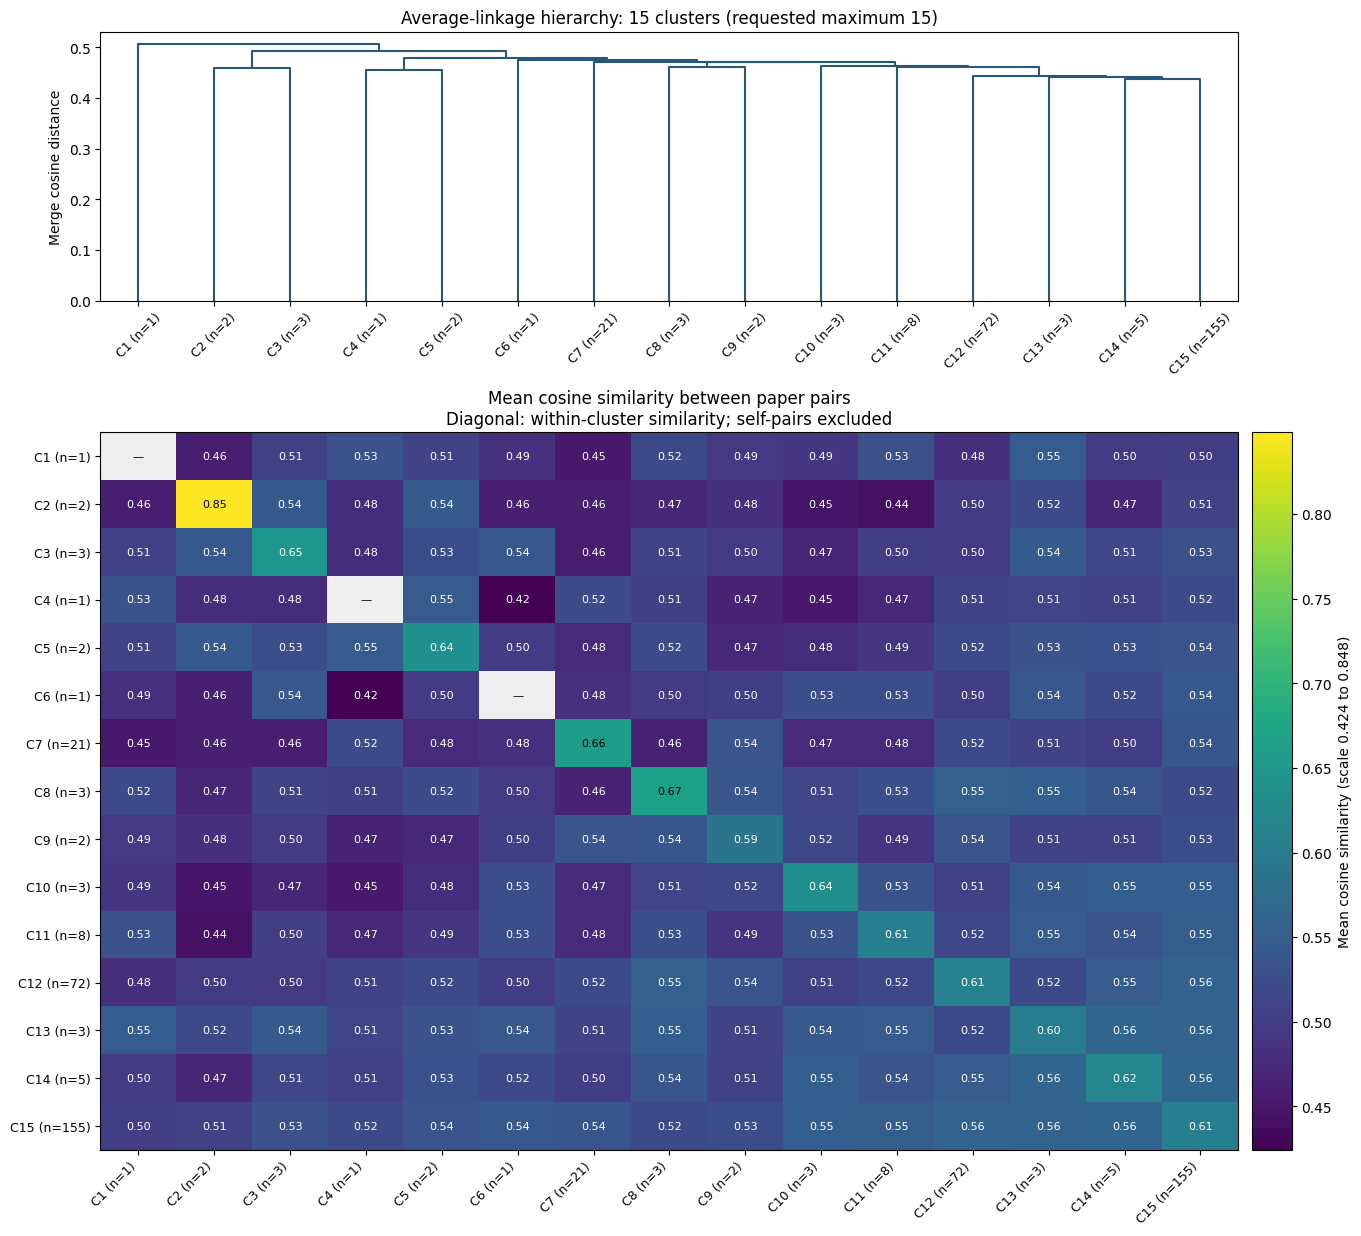

In [4]:
hierarchy_figure, hierarchy_axes = plot_cluster_hierarchy(
    hierarchy_clusters, color_limits=CLUSTER_HEATMAP_LIMITS,
)
plt.show()


### Cluster sizes and representative papers

Representatives have the highest mean cosine similarity to the other papers in their own cluster. They help explain its centre, but do not describe every member or automatically name its economic theme. Inspect the full membership when a group looks mixed. Titles are the selected PDF titles; inspect their accompanying abstracts when assessing a theme.


In [5]:
hierarchy_summary, hierarchy_papers = hierarchy_tables(
    hierarchy, hierarchy_clusters, papers, representatives=REPRESENTATIVE_PAPERS,
)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(hierarchy_summary.style.format(
        {'Within-cluster similarity': '{:.3f}'}, na_rep='—', escape='html',
    ).set_properties(subset=['Representative papers'], **{'white-space': 'pre-wrap'}))


,Cluster,Papers,Within-cluster similarity,Representative papers
0,C1,1,—,P172: Was there too little entry during the Dot Com Era?
1,C2,2,0.848,P134: The Sarbanes–Oxley Act and firms' going-private decisions P252: Was the Sarbanes–Oxley Act of 2002 really this costly? A discussion of evidence from event returns and going-private decisions
2,C3,3,0.647,P036: Size management by European private firms to minimize proprietary costs of disclosure P145: Regulatory costs of being public: Evidence from bunching estimation P054: Company Websites: A New Measure of Disclosure
3,C4,1,—,P144: Local Journalism under Private Equity Ownership
4,C5,2,0.638,P140: The Deregulation of the Private Equity Markets and the Decline in IPOs P257: The Incredible Shrinking Stock Market: On the Political Economy Consequences of Excessive Delistings
5,C6,1,—,P048: Private equity and regulatory capital
6,C7,21,0.663,"P192: Owner Incentives and Performance in Healthcare: Private Equity Investment in Nursing Homes P069: Changes in Hospital Income, Use, and Quality Associated With Private Equity Acquisition P275: Private Equity Investments In Health Care: An Overview Of Hospital And Health System Leveraged Buyouts, 2003–17"
7,C8,3,0.665,P007: The rise of dual-class stock IPOs P245: Consolidating corporate control Dual-class recapitalizations versus leveraged. buyouts P314: How Are U.S. Family Firms Controlled?
8,C9,2,0.588,P255: Syndicated loan spreads and the composition of the syndicate P268: How Deadly Is Financial Leverage? Evidence from Care Homes During the COVID-19 Crisis
9,C10,3,0.635,P096: What Do Impact Investors Do Differently? P165: Contracts with (Social) benefits: The implementation of impact investing P029: Journal of Financial Economics


### Copyable report for manual outlier review

The cell below prints plain text that you can select and copy. It lists **all titles for clusters of 1–2 papers**, and **three central representatives plus the full paper count for clusters of 3 or more**. It deliberately recomputes a three-representative summary regardless of the display setting above.

Small clusters that merge late are candidates for inspection, not automatic outliers. Check whether their papers concern a valid niche topic, whether the text/title extraction is correct, and whether they fit the scope of the private-equity map. Cluster size depends on the selected cut. Do not remove an in-scope paper solely to make the plot cleaner; record a substantive reason for any eventual exclusion. This cell excludes nothing and does not send the report to anyone.


In [6]:
from batill.clustering import cluster_review_report

review_summary, review_membership = hierarchy_tables(
    hierarchy, hierarchy_clusters, papers, representatives=3,
)
hierarchy_review_text = cluster_review_report(review_summary, review_membership)
print(f"Abstract embedding run: {ABSTRACT_RUN_DIR}")
print(f"Requested maximum clusters: {MAX_HIERARCHY_CLUSTERS}")
print()
print(hierarchy_review_text)


Abstract embedding run: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/selected_abstracts/embeddings/e606ddb5c9ddf172c49d/20261006T113841_841075Z_0d7099bb
Requested maximum clusters: 15

HIERARCHICAL CLUSTER REVIEW
Small clusters are review candidates, not confirmed outliers.
Titles are extracted metadata and may need correction.

C1 — 1 paper(s) — all papers; small-cluster review
  - P172: Was there too little entry during the Dot Com Era?

C2 — 2 paper(s) — all papers; small-cluster review
  - P134: The Sarbanes–Oxley Act and firms' going-private decisions
  - P252: Was the Sarbanes–Oxley Act of 2002 really this costly? A discussion of evidence from event returns and going-private decisions

C3 — 3 paper(s) — 3 representative papers
  - P036: Size management by European private firms to minimize proprietary costs of disclosure
  - P145: Regulatory costs of being public: Evidence from bunching estimation
  - P054: Company Websites: A New Measure of Disclosu

In [7]:
CLUSTER_TO_INSPECT = 'C1'  # Choose any cluster ID from the summary.
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(hierarchy_papers.loc[hierarchy_papers['Cluster'] == CLUSTER_TO_INSPECT])


,Cluster,Paper ID,Key,Title,source_filename,doi,year,journal,document_type,document_language,token_count,abstract_word_count
0,C1,P172,2722888e15c7c67a0249c47d80f3dc0af2c468cca9a1e7090671e9edd911b4bb,Was there too little entry during the Dot Com Era?,Goldfarb et al. - 2007 - Was there too little entry during the Dot Com Era.pdf,10.1016/j.jfineco.2006.03.009,2007,,,,164,121


### Optional paper-level detail

The cluster overview is the default. Enable the view below only to inspect individual papers in full hierarchy order. This detailed heatmap is not aggregated; its labels are the preserved Pxxx paper IDs. With thousands of papers, labels are thinned; use the membership tables and neighbours for detailed inspection. No figures, labels or tables are saved automatically.


In [8]:
SHOW_PAPER_LEVEL_HEATMAP = False
if SHOW_PAPER_LEVEL_HEATMAP:
    detail_figure, detail_axes = plot_hierarchy(
        hierarchy, papers['Paper ID'].to_numpy(),
        cut_distance=hierarchy_clusters['cut_distance'],
        color_limits=(-1.0, 1.0), max_tick_labels=35,
    )
    plt.show()


## 1. Inspect nearest neighbours

Cosine similarity measures proximity between embedding directions; it is not a probability. Inspect whether neighbours share a research question, mechanism, method, or setting. Broad vocabulary alone is weaker evidence.

The function below excludes the query paper itself. Start with five reproducibly sampled papers, then search for papers you know well and query them by `Key`.


In [9]:
# Reuse the hierarchy's exact cosine similarities if that section has run.
similarities = (hierarchy['similarity']
                if globals().get('_hierarchy_embeddings') is embeddings
                else cosine_similarity(embeddings))
key_to_row = {key: i for i, key in enumerate(keys)}

def nearest_papers(paper_key, top_n=TOP_N):
    if paper_key not in key_to_row:
        raise KeyError(f"Unknown selected PDF hash: {paper_key}")
    if isinstance(top_n, bool) or not isinstance(top_n, (int, np.integer)) or not 1 <= top_n < len(papers):
        raise ValueError(f"top_n must be between 1 and {len(papers) - 1}.")
    query_row = key_to_row[paper_key]
    scores = similarities[query_row].copy()
    scores[query_row] = -np.inf
    rows = np.argsort(-scores, kind='stable')[:top_n]
    result = papers.iloc[rows][[
        'Key', 'Title', 'year', 'journal', 'doi', 'token_count', 'text_preview'
    ]].copy()
    result.insert(0, 'rank', np.arange(1, len(rows) + 1))
    result.insert(1, 'cosine_similarity', scores[rows])
    return result.reset_index(drop=True)

def inspect_paper(paper_key, top_n=TOP_N, show_text=False):
    neighbours = nearest_papers(paper_key, top_n)
    query = papers.iloc[key_to_row[paper_key]]
    print(f"{query['Key']}: {query['Title']}")
    print(f"{query['year']} | {query['journal']} | DOI: {query['doi'] or '(missing)'}")
    if show_text:
        print('\nQuery abstract:', query['abstract'], '\n')
    visible = neighbours if show_text else neighbours.drop(columns='text_preview')
    with pd.option_context('display.max_colwidth', None):
        display(visible.style.format({'cosine_similarity': '{:.3f}'}, escape='html'))
    return neighbours

sample_keys = np.random.default_rng(RANDOM_STATE).choice(keys, size=min(5, len(keys)), replace=False)
for paper_key in sample_keys:
    inspect_paper(paper_key)
    print()


e002913268024f99119fba6a8aa361048b289017314a21b13542cc7e01cbce12: The Private Equity Experiment of U.S. Banking Industry
2025 |  | DOI: 10.2139/ssrn.5351770


,rank,cosine_similarity,Key,Title,year,journal,doi,token_count
0,1,0.752,0bab69d25c5bd9341b77c68fd0cb98e9829e6d946d0f3eaf56eb6b2ed7f0d117,Private Equity and Financial Stability: Evidence from Failed-Bank Resolution in the Crisis,2024,,10.1111/jofi.13399,182
1,2,0.722,e5b5fec065ec28e8067ec9771702661956b9fb0431aa404e3c461692c0ee800b,Private Equity and Financial Fragility during the Crisis,2018,,10.1093/rfs/hhy078,160
2,3,0.701,00c2efde17c288cc4527106485d6d44923813c305d725f4eb88c70ab0803e1f8,Private equity for pension plans? Evaluating private equity performance from an investor's perspective,2024,,10.1016/j.jfineco.2026.104336,154
3,4,0.699,31eac09890a99a21ac98202afbf5a1b327c9c5de09a639038b2019fdcf861e8d,Combining Banking with Private Equity Investing,2013,,10.1093/rfs/hht031,155
4,5,0.698,65223bbb6f91f64989e5baac7260b0c6aeb7c933865fbb31e18f7c0640e21014,What Private Equity Does Differently: Evidence from Life Insurance,2023,,10.1093/rfs/hhad055,175



80aca52b081d5eec089aca116fd3e552dc0769b8c762547896e165e474d595ad: When Investor Incentives and Consumer Interests Diverge: Private Equity in Higher Education
2019 |  | DOI: 10.1093/rfs/hhz129


,rank,cosine_similarity,Key,Title,year,journal,doi,token_count
0,1,0.737,75c43b635111348f28dac74e46c974668e6faea95f3c9f94995dd9405d9639af,Private Equity Lemons? Evidence on Value Creation in Secondary Buyouts,2012,,10.1111/j.1468-036x.2012.00644.x,158
1,2,0.736,11130f251beb5d7ea230dda58886a8ad1b245dec64922eb2bb85639f97f87fc8,Winning a deal in private equity: Do educational ties matter?,2020,,10.1016/j.jcorpfin.2020.101740,208
2,3,0.712,6eaf2ce8daed55e2f19ff3074b26dfb09edaba47ee32a03122dac75a905282b6,Politically Connected Private Equity and Employment,2017,,10.1111/jofi.12483,156
3,4,0.707,f36a32771977dc14aef29be6b8c0e6318b7eaa37105e895defffc195aa1fedb5,The (Heterogeneous) Economic Effects of Private Equity Buyouts,2025,,10.1287/mnsc.2021.03890,304
4,5,0.701,078c6aa70115095c7fa14f854d8c3cfa28b56a056da200607eb4afb343ed8b21,Do Employees Cheer for Private Equity? The Heterogeneous Effects of Buyouts on Job Quality,2024,,10.1287/mnsc.2022.00951,157



f841b594e2ebb52a36d4151e8efca5c3722908deb3608778684de8b0e44f998d: ALL CLEAR FOR TAKEOFF: EVIDENCE FROM AIRPORTS ON THE EFFECTS OF INFRASTRUCTURE PRIVATIZATION
2022 |  | DOI: 10.1093/rfs/hhag023


,rank,cosine_similarity,Key,Title,year,journal,doi,token_count
0,1,0.724,4b6388b60930fe0b3750eaa738fb8f546ffd6d3e3ac3b4910bdcee8a64013af8,Earnings Quality and Ownership Structure: The Role of Private Equity Sponsors,2009,,10.2308/accr.2009.84.3.623,214
1,2,0.703,a6d71ec25cda7161319f91d35bba102aa484dac991f7dbfeba0a2e7cac562d72,Does Private Equity Ownership Make Firms Cleaner? The Role of Environmental Liability Risks,2025,,10.1093/rfs/hhaf035,189
2,3,0.702,20625270cdb2ee678f26d394a76df99dd0145ca10f79d5f234216134d9928bb8,Sources of Value Creation in Private Equity Buyouts of Private Firms,2022,,10.1093/rof/rfac005,174
3,4,0.672,b9b50f74a737075e4fbe1ebefcdfa97ea0e0727e03ecf1ee49567a9eab685002,Agency Problems in Public Firms: Evidence from Corporate Jets in Leveraged Buyouts,2012,,10.1111/j.1540-6261.2012.01784.x,160
4,5,0.670,f8a8d67f8973a5a1bbc2ace2e8183cc1477bf57adda2a32f1d5dbcaf48151d94,Playing to their strengths? Evidence that specialization in the private equity industry confers competitive advantage,2007,,10.1016/j.jcorpfin.2007.04.007,310



23ee0e60779f15efb15bf4d35b6deca2719ac7ad21cf1b1415a9e99accf0ba7e: Private Ownership and the Cost of Public Debt: Evidence from the Bond Market
2018 |  | DOI: 10.1287/mnsc.2017.2935


,rank,cosine_similarity,Key,Title,year,journal,doi,token_count
0,1,0.756,152e7b480099a4669b25b02e9d5606a28cfcc944177969b10ab864d39f872c8b,The Effects of Public and Private Equity Markets on Firm Behavior,2022,,10.1146/annurev-financial-052021-072939,209
1,2,0.703,c4037a96d32088d9d200b036d2bc546436e704ca9667c78947384a4ac13c58dd,Lemons or Cherries? Growth Opportunities and Market Temptations in Going Public and Private,2010,,10.1017/s0022109010000761,197
2,3,0.702,5bae6783052fee787250228c68d775577588280c975b7cc84a01fa6a221992e8,Why Do Firms Use Private Equity to Opt Out of Public Markets?,2010,,10.1093/rfs/hhq016,206
3,4,0.701,821aaf3bb89c128210af14ad6ac6d310fcac1805e5e79d37af4bf30d1aaf5d13,Private Equity and Corporate Governance: Retrospect and Prospect,2009,,10.1111/j.1467-8683.2009.00744.x,621
4,5,0.700,c602e64ec46fdce5a09ab2776cc8a157c47a860fea78cd3a9306d3c779300392,Institutional Liquidity Needs and the Structure of Monitored Finance,2003,,10.1093/rfs/hhg042,174



5b8aebc86a86030cf4499111d58b93630902d7b2692a186468ae30e7e280ad71: Private Equity Fund Reporting Quality, External Monitors, and Third-Party Service Providers
2024 |  | DOI: 10.2308/tar-2023-0291


,rank,cosine_similarity,Key,Title,year,journal,doi,token_count
0,1,0.757,060daaac8bdff5437b007a9d5b41e738e05c0cd3c23d74357ab7c279058483a6,Private equity returns and disclosure around the world,2009,,10.1057/jibs.2009.62,142
1,2,0.725,eff52c4326000645560c302e9e088debc6596d3fe249b7e6bcffe7bfff0e4b3f,Financial Reporting Quality in Private Equity Backed Companies: The Impact of Ownership Concentration Christof Beuselinck,2007,,10.1007/s11187-006-9022-1,173
2,3,0.724,91b43a24dfc7ceb2f38f93746c7943ca2e0962e45c533a87943d7970e54a9dff,The Performance of Private Equity Funds,2008,,10.1093/rfs/hhn014,148
3,4,0.711,24b1057b780d4a0b2cb2258de541e91249d5bee71accd25229cd430fabf6bbab,Do Private Equity Managers Have Superior Information on Public Markets?,2021,,10.1017/s0022109021000107,135
4,5,0.709,41044b481be1200f9b56902696ffbae4ec27f8d004ab00fc1ea3781efa330e74,What Do Different Commercial Data Sets Tell Us About Private Equity Performance?,2015,,10.2139/ssrn.2701317,191


In [10]:
# Change the search term, then copy a Key into the next cell.
SEARCH_TERM = "buyout"
matches = papers["Title"].str.contains(SEARCH_TERM, case=False, regex=False)
display(papers.loc[matches, ["Key", "Title", "year", "journal", "doi"]].head(20))


,Key,Title,year,journal,doi
1,2d3b2ba746ed713cfe70a748672f6eda554db7a371c1bb...,What drives leverage in leveraged buyouts? An ...,2011,,10.1111/j.1467-629x.2011.00431.x
3,288b181ec747cc2e900ef707239969720d711dfcbd0af6...,"More insiders, more insider trading: Evidence ...",2010,,10.1016/j.jfineco.2010.08.002
4,2a21b697e4f775b6651ffcbee7ea664921c6067a5c4232...,Structure and Determinants of Financial Covena...,2011,,10.1093/rof/rfq031
10,427f865cd132c124d3730252ca2228fa4203b77b5ca780...,"Leveraged buyouts, private equity and jobs",2010,,10.1007/s11187-010-9280-9
15,7b5e1546a2419438cc557f16aee95277c4023f0654d0e4...,Private Equity Buyouts in Healthcare: Who Wins...,2020,,10.36687/inetwp118
16,9d8f8313189e45bf982dc6a17f6f1288ae7598027aa289...,Fund managers under pressure: Rationale and de...,2014,,10.1016/j.jfineco.2014.08.002
18,e6251c6079bb34d2e3f83028a4eae7028e5af8805be7e1...,"Event risk, covenants, and bondholder returns ...",1990,,10.1016/0304-405x(90)90026-v
19,741967ca9a4eb2faed548028285e9e254e8a77147037db...,Why Are Buyouts Levered? The Financial Structu...,2009,,10.1111/j.1540-6261.2009.01473.x
20,483d51dc0085e76ae07e90df790b9d009198c8bafad94e...,"Borrow Cheap, Buy High? The Determinants of Le...",2013,,10.1111/jofi.12082
27,5cf091d56bc84240ec2a34eb85a396ade994bb897907c9...,ORGANIZATIONAL CHANGES AYD VALUE CREATION IN L...,1989,,10.1016/0304-405x(89)90080-9


In [11]:
# Replace this with a Key from the search results to inspect a specific paper.
QUERY_KEY = str(sample_keys[0])
neighbours = inspect_paper(QUERY_KEY, top_n=TOP_N, show_text=True)


e002913268024f99119fba6a8aa361048b289017314a21b13542cc7e01cbce12: The Private Equity Experiment of U.S. Banking Industry
2025 |  | DOI: 10.2139/ssrn.5351770

Query abstract: We examine 172 private equity (PE) investments in 87 publicly traded banks during and after the global financial crisis, enabled by relaxed Federal Reserve regulations aimed at recapitalizing banks. Risk indicators, including market- and accounting-based metrics worsened at these PE-backed banks. CEOs were incentivized to take on more risk, leading to accelerated business lending, increased asset-backed and mortgage-backed securities as well as trading assets holdings, and deteriorated business credit quality. But PE investment added value. Bank share prices appreciated relative to the market in both the short-run and the long-run, comparable to contemporary PE deals in less regulated industries. 



,rank,cosine_similarity,Key,Title,year,journal,doi,token_count,text_preview
0,1,0.752,0bab69d25c5bd9341b77c68fd0cb98e9829e6d946d0f3eaf56eb6b2ed7f0d117,Private Equity and Financial Stability: Evidence from Failed-Bank Resolution in the Crisis,2024,,10.1111/jofi.13399,182,"This paper investigates the role of private equity (PE) in failed-bank resolutions after the 2008 financial crisis, using proprietary Federal Deposit Insurance Corporation failed-bank acquisition data. PE investors made substantial investments in underperforming and riskier failed banks, particularly in geographies where local banks were also distressed, filling the gap created by a weak, undercapitalized banking sector. Using a quasi-random empirical design based on detailed bidding information, we show that PE-acquired banks performed better ex post, with positive real effects for the local economy. Overall, PE investors played a positive role in stabilizing the financial system through their involvement in failed-bank resolution."
1,2,0.722,e5b5fec065ec28e8067ec9771702661956b9fb0431aa404e3c461692c0ee800b,Private Equity and Financial Fragility during the Crisis,2018,,10.1093/rfs/hhy078,160,"Does private equity (PE) contribute to financial fragility during economic crises? The proliferation of poorly structured transactions during booms may increase the vulnerability of the economy to downturns. During the 2008 crisis, PE-backed companies decreased investments less than did their peers and experienced greater equity and debt inflows, higher asset growth, and increased market share. These effects are especially strong among financially constrained companies and those whose PE investors had more resources at the crisis onset. In a survey, PE firms report being active investors during the crisis and spending more time working with their portfolio companies. (JEL G34, G30, G01)"
2,3,0.701,00c2efde17c288cc4527106485d6d44923813c305d725f4eb88c70ab0803e1f8,Private equity for pension plans? Evaluating private equity performance from an investor's perspective,2024,,10.1016/j.jfineco.2026.104336,154,"We evaluate private equity (PE) performance using investor-specific stochastic discount factors, and examine whether public pension plans could benefit from changing their allocation to PE. Plans invest in PE funds with higher than average risk-adjusted performance. This is mainly due to access to successful managers, not superior selection skill. Decomposing returns into risk-compensation and ''alpha'', we find that some plans obtain higher PE returns by taking more risk without earning higher, and in some cases earning lower, risk-adjusted returns, broadly consistent with agency problems within plans."
3,4,0.699,31eac09890a99a21ac98202afbf5a1b327c9c5de09a639038b2019fdcf861e8d,Combining Banking with Private Equity Investing,2013,,10.1093/rfs/hht031,155,"Bank-affiliated private equity groups account for 30% of all private equity investments. Their market share is highest during peaks of the private equity market, when the parent banks arrange more debt financing for in-house transactions yet have the lowest exposure to debt. Using financing terms and ex post performance, we show overall that banks do not make superior equity investments to those of stand-alone private equity groups. Instead, they appear to expand their private equity engagement to take advantage of the credit market booms, while capturing private benefits from cross-selling of other banking services. (JEL G20, G21, G24)"
4,5,0.698,65223bbb6f91f64989e5baac7260b0c6aeb7c933865fbb31e18f7c0640e21014,What Private Equity Does Differently: Evidence from Life Insurance,2023,,10.1093/rfs/hhad055,175,"This paper studies how private equity creates value and its consequences for consumer welfare in the insurance industry, where PE investments grew tenfold following the financial crisis. PE firms add value through regulatory and tax arbitrage that increases profits relative to their non-PE counterparts. Crucially, the im

## 2a. PCA

PCA is a deterministic linear projection. Its explained-variance percentages show how much of the original variation these two axes retain. A low percentage means that substantial structure is omitted from this view.


In [12]:
pca = PCA(n_components=2, svd_solver="full")
pca_coordinates = pca.fit_transform(embeddings)
papers["PCA 1"] = pca_coordinates[:, 0]
papers["PCA 2"] = pca_coordinates[:, 1]
assert np.isfinite(pca_coordinates).all()
print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance shown: {pca.explained_variance_ratio_.sum():.1%}")


PC1 explained variance: 6.2%
PC2 explained variance: 4.5%
Total variance shown: 10.7%


In [13]:
try:
    import plotly.express as px
except ImportError as exc:
    raise ImportError("Install the project's analysis extra in this kernel, then rerun.") from exc

def hover_text(value, width=70):
    return '<br>'.join(html.escape(line) for line in textwrap.wrap(str(value), width=width))

plot_data = papers.copy()
plot_data['Paper'] = plot_data['Title'].map(hover_text)
plot_data['Text preview'] = plot_data['text_preview'].map(
    lambda text: hover_text(text[:350] + ('…' if len(text) > 350 else ''))
)
# Hover labels escape externally supplied metadata as well as titles/abstracts.
for column in ['journal', 'doi', 'year', 'document_type', 'document_language']:
    plot_data[column] = plot_data[column].map(html.escape)

def embedding_plot(frame, x, y, title):
    fig = px.scatter(
        frame, x=x, y=y, render_mode='webgl',
        hover_name='Paper',
        hover_data={'Key': True, 'year': True, 'journal': True, 'doi': True,
                    'Text preview': True, 'token_count': True,
                    'abstract_word_count': True, x: False, y: False},
        labels={'token_count': 'Title + abstract tokens',
                'abstract_word_count': 'Abstract words'},
        title=title, template='plotly_white', height=650,
    )
    fig.update_traces(marker={'size': POINT_SIZE, 'opacity': POINT_OPACITY, 'color': '#3573A5'})
    return fig

pca_figure = embedding_plot(plot_data, 'PCA 1', 'PCA 2', 'Abstract embeddings in PCA space')
pca_figure.update_xaxes(title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
pca_figure.update_yaxes(title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
pca_figure.show()


## 2b. UMAP

UMAP emphasizes neighbourhood structure and can reveal nonlinear patterns. This view uses cosine distance on the original embeddings, with a fixed seed for reproducibility. The axes have no direct semantic meaning, and apparent islands are not proof of distinct research topics.

`n_neighbors` controls the balance between local and broader structure; `min_dist` controls how tightly points can pack in the plot. All inputs are complete title-and-abstract pairs, so this unclustered view uses a single colour. Compare the same papers in both projections; the later views colour them by cluster.


In [14]:
try:
    import umap
except ImportError as exc:
    raise ImportError("Install UMAP in this kernel with %pip install umap-learn, then rerun this cell.") from exc

UMAP_NEIGHBOURS = min(15, len(papers) - 1)
UMAP_MIN_DIST = 0.1
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBOURS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
umap_coordinates = reducer.fit_transform(embeddings)
assert umap_coordinates.shape == (len(papers), 2) and np.isfinite(umap_coordinates).all()
papers["UMAP 1"] = plot_data["UMAP 1"] = umap_coordinates[:, 0]
papers["UMAP 2"] = plot_data["UMAP 2"] = umap_coordinates[:, 1]
umap_figure = embedding_plot(plot_data, "UMAP 1", "UMAP 2", "Abstract embeddings in UMAP space")
umap_figure.show()


/Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Compare neighbourhood preservation

Trustworthiness (0–1; higher is better) measures whether neighbours in the 2D projection were neighbours in the original space. We use cosine distance in that original space and up to 15 neighbours for both projections (fewer for small corpora). This is a projection diagnostic, not a measure of thematic correctness or clustering quality.


In [15]:
CHECK_NEIGHBOURS = min(15, (len(papers) - 1) // 2)
if CHECK_NEIGHBOURS < 1:
    raise ValueError('Trustworthiness requires at least three papers.')
projection_checks = pd.DataFrame({
    'Projection': ['PCA', 'UMAP'],
    f'Trustworthiness ({CHECK_NEIGHBOURS} neighbours)': [
        trustworthiness(embeddings, pca_coordinates, n_neighbors=CHECK_NEIGHBOURS, metric='cosine'),
        trustworthiness(embeddings, umap_coordinates, n_neighbors=CHECK_NEIGHBOURS, metric='cosine'),
    ],
})
display(projection_checks)

,Projection,Trustworthiness (15 neighbours)
0,PCA,0.749382
1,UMAP,0.844253


Record observations below before choosing a clustering method: do neighbours share a research question or merely vocabulary? Are any papers unexpectedly close? Do short abstracts and papers from different publication years have plausible neighbours? Avoid assigning topics from the 2D layout alone.

**Review notes:**

- Paper keys examined:
- Neighbours that make sense and why:
- Questionable matches:
- Differences between PCA and UMAP:

The final partition handoff cell saves the text assignments for topic interpretation. `papers` holds the aligned metadata and projection coordinates for the clustering comparison below.


## Leiden: communities in a weighted similarity graph

Each paper is a node. We connect it to its nearest neighbours using cosine similarity in the **original embedding space**, not PCA or UMAP. The default undirected **union kNN** graph includes an edge if either paper selects the other. `LEIDEN_MUTUAL = True` requires both directions and can fragment the graph more strongly. Edge weights are the original positive cosine similarities; self-edges, zero and negative similarities are omitted, not shifted into positive weights. All papers remain nodes.

Leiden optimizes the weighted **RB configuration objective**, with a resolution parameter. Higher resolution generally favours smaller communities; it is not a requested cluster count. We inspect resolutions that yield **2–15 communities**, without forcing or silently merging groups. Graph sparsity, threshold and resolution all affect the answer. Disconnected components and isolated papers can prevent a useful small partition.

Install dependencies once in the selected kernel if needed: `%pip install igraph leidenalg`. The implementation is in `src/batill/graph_clustering.py`. These cells require only setup/loading above and do not require hierarchical clustering to have run. [Leiden API and objective documentation](https://leidenalg.readthedocs.io/en/stable/reference.html).


In [16]:
from batill.graph_clustering import similarity_graph, leiden_sweep, leiden_tables

LEIDEN_NEIGHBOURS = 15
LEIDEN_MIN_SIMILARITY = 0.0  # Keep only weights strictly above this threshold.
LEIDEN_MUTUAL = False
# Systematic grid: 0.10 to 0.95; np.arange excludes 1.0.
LEIDEN_RESOLUTIONS = np.round(np.arange(0.1, 2.0, 0.1), 2).tolist()
LEIDEN_INSPECTION_DEFAULT = 0.5  # Inspection setting only; choose a final resolution after review.
LEIDEN_SEEDS = [42, 43, 44]
LEIDEN_MAX_CLUSTERS = 15

from batill.abstract_topic_analysis import abstract_partition_input_id
leiden_fit_input_id = abstract_partition_input_id(papers.Key, embeddings)
leiden_graph = similarity_graph(
    embeddings, neighbours=LEIDEN_NEIGHBOURS,
    min_similarity=LEIDEN_MIN_SIMILARITY, mutual=LEIDEN_MUTUAL,
)
display(pd.DataFrame([leiden_graph['diagnostics']]))
print('Effective neighbours per paper before symmetrizing:', leiden_graph['neighbours'])
if leiden_graph['diagnostics']['isolated_papers']:
    print('Some papers have no edges. Inspect them; they are retained, not dropped.')
if leiden_graph['diagnostics']['components'] > LEIDEN_MAX_CLUSTERS:
    print('More disconnected components than the target maximum. Review graph construction first.')


,papers,edges,components,isolated_papers,min_degree,median_degree,max_degree
0,282,3115,1,0,15,19.0,74


Effective neighbours per paper before symmetrizing: 15


### Resolution, cluster sizes and stability

Each resolution is run with three seeds. The highest-objective run **within that resolution** supplies the reported partition; objectives are not ranked across resolutions. ARI reports seed agreement on this fixed graph (1 means identical partitions), not scientific validity. Cosine silhouette uses original paper distances, including pairs that have no graph edge. It is undefined for a single cluster or all-singleton partition.

Review the complete table and the 2–15-community candidates. Singleton counts and very large groups are useful warnings. If none fit the target, change the resolution range or graph settings explicitly. No resolution is automatically accepted as the final thesis partition.


,resolution,clusters,within_target,smallest,largest,singletons,cosine_silhouette,seed_stability_ARI,selected_seed
0,0.1,1,False,282,282,0,NaN,1.000000,42
1,0.2,2,True,20,262,0,0.116166,0.333333,42
2,0.3,3,True,20,182,0,0.103058,0.509833,43
3,0.4,3,True,21,174,0,0.104227,0.569709,44
4,0.5,3,True,21,172,0,0.103765,0.742698,43
5,0.6,4,True,21,111,0,0.091412,0.863955,43
6,0.7,4,True,21,110,0,0.092039,0.961818,43
7,0.8,4,True,21,108,0,0.091198,0.964760,42
8,0.9,4,True,22,108,0,0.091101,1.000000,42
9,1.0,4,True,24,107,0,0.090352,0.868354,44


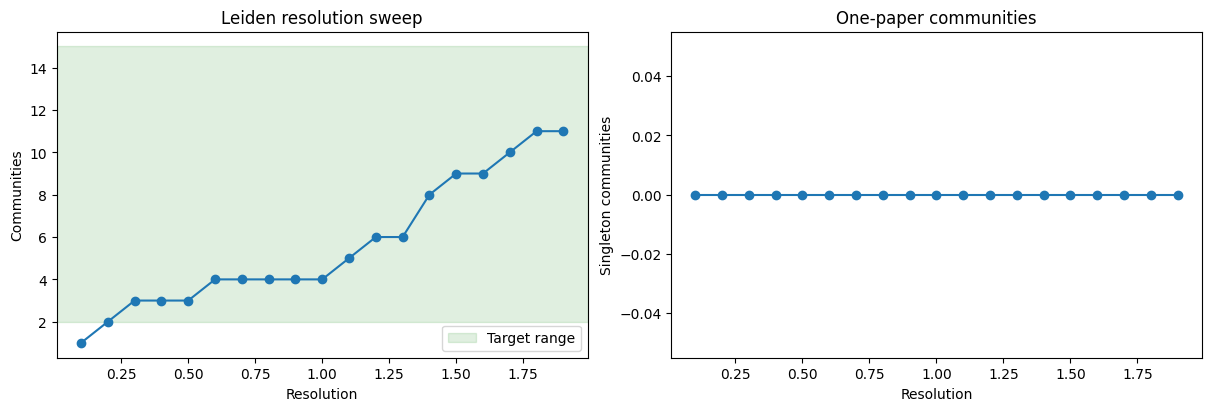

In [17]:
leiden_diagnostics, leiden_results = leiden_sweep(
    leiden_graph, LEIDEN_RESOLUTIONS, seeds=LEIDEN_SEEDS,
    max_clusters=LEIDEN_MAX_CLUSTERS,
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(leiden_diagnostics)
leiden_candidates = leiden_diagnostics.loc[leiden_diagnostics['within_target']]
#print('Candidates within the requested cluster-count range:')
#display(leiden_candidates)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].plot(leiden_diagnostics['resolution'], leiden_diagnostics['clusters'], 'o-')
axes[0].axhspan(2, LEIDEN_MAX_CLUSTERS, alpha=.12, color='green', label='Target range')
axes[0].set(xlabel='Resolution', ylabel='Communities', title='Leiden resolution sweep')
axes[0].legend()
axes[1].plot(leiden_diagnostics['resolution'], leiden_diagnostics['singletons'], 'o-')
axes[1].set(xlabel='Resolution', ylabel='Singleton communities', title='One-paper communities')
plt.show()

### Inspect a selected resolution

Set `LEIDEN_INSPECT_RESOLUTION` to a value from the sweep. The default is resolution 0.5; inspect its actual community count for the active corpus. L1, L2, … identify Leiden communities and have no relationship to C1, C2, … from the hierarchy. Representatives are the members most similar on average to the other papers in their community. Titles and abstracts should be reviewed together.


,Cluster,Papers,Within-cluster similarity,Representative papers
0,L1,172,0.591,P236: Private equity for pension plans? Evaluating private equity performance from an investor's perspective P284: Beware of Venturing into Private Equity P294: Decreasing Returns or Reversion to the Mean? The Case of Private Equity Fund Growth
1,L2,89,0.599,"P281: Consequences of leveraged buyouts P117: The (Heterogeneous) Economic Effects of Private Equity Buyouts P021: Borrow Cheap, Buy High? The Determinants of Leverage and Pricing in Buyouts"
2,L3,21,0.657,"P192: Owner Incentives and Performance in Healthcare: Private Equity Investment in Nursing Homes P069: Changes in Hospital Income, Use, and Quality Associated With Private Equity Acquisition P061: Association of Private Equity Investment in US Nursing Homes With the Quality and Cost of Care for Long-Stay Residents"


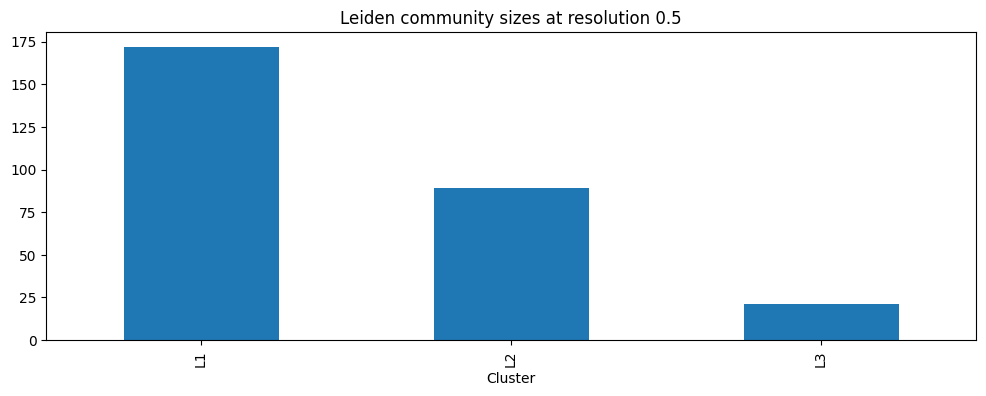

In [18]:
LEIDEN_INSPECT_RESOLUTION = LEIDEN_INSPECTION_DEFAULT
# Accept results already computed with an unrounded np.arange grid.
_resolution_matches = [r for r in leiden_results
                       if np.isclose(float(r), LEIDEN_INSPECT_RESOLUTION, rtol=0, atol=1e-12)]
if len(_resolution_matches) != 1:
    raise ValueError(f'Resolution {LEIDEN_INSPECT_RESOLUTION:g} is missing or ambiguous. '
                     f'Available fitted resolutions: {sorted(leiden_results)}. Rerun the sweep if needed.')
LEIDEN_INSPECT_RESOLUTION = _resolution_matches[0]
leiden_selected = leiden_results[LEIDEN_INSPECT_RESOLUTION]
leiden_labels = leiden_selected['labels']  # Same row order as embeddings and papers.
leiden_summary, leiden_papers = leiden_tables(leiden_graph, leiden_selected, papers, representatives=3)
if not 2 <= len(leiden_summary) <= LEIDEN_MAX_CLUSTERS:
    print('This resolution is outside the target range. Inspect another candidate in the table above.')
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(leiden_summary.style.format(
        {'Within-cluster similarity': '{:.3f}'}, na_rep='—', escape='html',
    ).set_properties(subset=['Representative papers'], **{'white-space': 'pre-wrap'}))
ax = leiden_summary.plot.bar(x='Cluster', y='Papers', legend=False, figsize=(12, 4))
ax.set_title(f'Leiden community sizes at resolution {LEIDEN_INSPECT_RESOLUTION}')
plt.show()


In [19]:
LEIDEN_CLUSTER_TO_INSPECT = 'L1'
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(leiden_papers.loc[leiden_papers['Cluster'] == LEIDEN_CLUSTER_TO_INSPECT])


,Cluster,Paper ID,Key,Title,source_filename,doi,year,journal,document_type,document_language,token_count,abstract_word_count
0,L1,P001,b87701a573df443374b263f59e2706fb6b0fb7c9286c6c832b3d8d59d33f0ae1,ESG Disclosures in the Private Equity Industry,Abraham et al. - 2024 - ESG Disclosures in the Private Equity Industry.pdf,10.1111/1475-679x.12570,2024,,,,203,127
1,L1,P003,d52328858a91e1b966a1afcbec8e586e9326a702a95519d187d78319623f32f1,Corporate Governance and Value Creation: Evidence from Private Equity,Acharya et al. - 2013 - Corporate Governance and Value Creation Evidence from Private Equity.pdf,10.1093/rfs/hhs117,2012,,,,198,109
2,L1,P009,7c384e8c83b717df2ec9584862eeef02d71579b4a29a5b349a34a4d902017a35,Liquidity Provision in the Secondary Market for Private Equity Fund Stakes,Albuquerque et al. - 2018 - Liquidity Provision in the Secondary Market for Private Equity Fund Stakes.pdf,10.2139/ssrn.3182481,2018,,,,165,105
3,L1,P010,230d44d09f96d2c7769aadfff1930080d1e7c2b4b45cd8121f45369de5c20dc8,Private equity in the global economy: Evidence on industry spillovers,Aldatmaz und Brown - 2020 - Private equity in the global economy Evidence on industry spillovers.pdf,10.1016/j.jcorpfin.2019.101524,2019,,,,169,100
4,L1,P012,d3749652d927d0d2a5d65b92c772a1c3ad84708b05a3aff2a162b29cb5e964d9,Political Representation and Governance: Evidence from the Investment Decisions of Public Pension Funds,Andonov et al. - 2018 - Political Representation and Governance Evidence from the Investment Decisions of Public Pension Funds.pdf,10.1111/jofi.12706,2018,,,,154,85
5,L1,P013,de42e5a60a76ce11234a2199a4de0f716f2231a873115c26905ed50dd9dc135a,UvA-DARE (Digital Academic Repository),Andonov et al. - 2021 - Institutional Investors and Infrastructure Investing.pdf,10.1093/rfs/hhab048,2021,,,,183,104
6,L1,P014,1cc25d3a982fd554bb1f4218a91b0d3068087499e1871bba16b88d7b833eb1f9,Estimating Private Equity Returns from Limited Partner Cash Flows,Ang et al. - 2018 - Estimating Private Equity Returns from Limited Partner Cash Flows.pdf,10.1111/jofi.12688,2018,,,,152,96
7,L1,P018,c4037a96d32088d9d200b036d2bc546436e704ca9667c78947384a4ac13c58dd,Lemons or Cherries? Growth Opportunities and Market Temptations in Going Public and Private,Aslan und Kumar - 2011 - Lemons or Cherries Growth Opportunities and Market Temptations in Going Public and Private.pdf,10.1017/s0022109010000761,2010,,,,197,118
8,L1,P020,741967ca9a4eb2faed548028285e9e254e8a77147037db3bbeaf102a76a89919,Why Are Buyouts Levered? The Financial Structure of Private Equity Funds,Axelson et al. - 2009 - Why Are Buyouts Levered The Financial Structure of Private Equity Funds.pdf,10.1111/j.1540-6261.2009.01473.x,2009,,,,170,98
9,L1,P024,1b2fc7f766f98eb98d5d3ac13a7b16f31eab1fd09300c29cd6a74dfa19dc7993,The separation of ownership and control and corporate tax avoidance,Badertscher et al. - 2013 - The separation of ownership and control and corporate tax avoidance.pdf,10.1016/j.jacceco.2013.08.005,2013,,,,239,165


Before choosing a partition, inspect the themes and outliers and repeat with a few neighbour counts (for example 10, 15 and 25). Stable random-seed results do not establish robustness to graph construction or embedding choices. Leiden does not guarantee balanced sizes or eliminate singletons. All results remain in memory; these cells do not recompute embeddings or export assignments.


### PCA and UMAP coloured by the chosen Leiden resolution

Choose any resolution already computed in the sweep. These plots reuse the earlier PCA and UMAP coordinates; **Leiden is still fitted to the original embedding similarity graph**. Both plots use the same community colours. Changing this resolution only changes the displayed labels; it does not refit projections or overwrite the resolution used by the previous representative table. Both controls default to SELECTED_LEIDEN_RESOLUTION in the graph setup cell.


In [20]:
LEIDEN_PLOT_RESOLUTION = LEIDEN_INSPECTION_DEFAULT
# Accept results already computed with an unrounded np.arange grid.
_resolution_matches = [r for r in leiden_results
                       if np.isclose(float(r), LEIDEN_PLOT_RESOLUTION, rtol=0, atol=1e-12)]
if len(_resolution_matches) != 1:
    raise ValueError(f'Resolution {LEIDEN_PLOT_RESOLUTION:g} is missing or ambiguous. '
                     f'Available fitted resolutions: {sorted(leiden_results)}. Rerun the sweep if needed.')
LEIDEN_PLOT_RESOLUTION = _resolution_matches[0]
required_columns = ['PCA 1', 'PCA 2', 'UMAP 1', 'UMAP 2']
if any(column not in plot_data for column in required_columns):
    raise RuntimeError('Run the earlier PCA and UMAP cells before this view.')

leiden_projection = plot_data.copy()
plot_labels = leiden_results[LEIDEN_PLOT_RESOLUTION]['labels']
assert len(plot_labels) == len(leiden_projection)
leiden_projection['Leiden community'] = [f'L{i}' for i in plot_labels]
community_order = [f'L{i}' for i in sorted(np.unique(plot_labels))]
community_colors = {
    label: px.colors.qualitative.Alphabet[i % len(px.colors.qualitative.Alphabet)]
    for i, label in enumerate(community_order)
}
leiden_projection_figures = []
for x, y, projection in [('PCA 1', 'PCA 2', 'PCA'), ('UMAP 1', 'UMAP 2', 'UMAP')]:
    figure = px.scatter(
        leiden_projection, x=x, y=y, color='Leiden community', render_mode='webgl',
        category_orders={'Leiden community': community_order}, color_discrete_map=community_colors,
        hover_name='Paper', hover_data={'Key': True, 'year': True, 'journal': True, 'doi': True,
            'token_count': True, 'Text preview': True, x: False, y: False},
        title=f'Leiden resolution {LEIDEN_PLOT_RESOLUTION}: {len(community_order)} communities in {projection}',
        template='plotly_white', height=650,
    )
    figure.update_traces(marker={'size': POINT_SIZE, 'opacity': POINT_OPACITY})
    if projection == 'PCA':
        figure.update_xaxes(title=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
        figure.update_yaxes(title=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    figure.show()
    leiden_projection_figures.append(figure)


## 3. Compare cluster counts: K-means, k = 2–15

Fit K-means to the original normalized full-dimensional embeddings, not the PCA/UMAP coordinates. Standard K-means optimizes squared Euclidean distance to its centroids; cosine silhouette provides a complementary check of angular separation between papers.

For each k, run five seeds with ten initializations per seed. Retain the fit with the lowest inertia, independently of its silhouette score. Also cluster five random 80% subsamples. Compare seed runs using Adjusted Rand Index (ARI), and subsample runs using ARI on their shared papers. ARI = 1 means identical groupings, approximately 0 means chance-level agreement; negative values are possible. Stability alone does not establish meaningful topics.

This is an exploratory search range, not a claim that the true number of themes lies within it. If promising results occur at k = 15, consider extending the range.


In [21]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
from threadpoolctl import threadpool_limits

MAX_K = 15
SUBSAMPLE_FRACTION = 0.8
K_VALUES = list(range(2, min(MAX_K, int(len(embeddings) * SUBSAMPLE_FRACTION) - 1) + 1))
if not K_VALUES:
    raise ValueError("Too few papers for this cluster-count sweep.")
KMEANS_SEEDS = [11, 22, 33, 44, 55]
N_INIT = 10
SUBSAMPLE_SEEDS = [101, 202, 303, 404, 505]

assert max(K_VALUES) < int(len(embeddings) * SUBSAMPLE_FRACTION)
# Reuse exact full-corpus distances; no projection or silhouette subsampling.
if globals().get('_hierarchy_embeddings') is embeddings:
    distance_matrix = hierarchy['distance']
else:
    distance_matrix = cosine_distances(embeddings)
    distance_matrix = np.maximum((distance_matrix + distance_matrix.T) / 2, 0)
    np.fill_diagonal(distance_matrix, 0)

subsample_indices = [
    np.sort(np.random.default_rng(seed).choice(
        len(embeddings), size=int(len(embeddings) * SUBSAMPLE_FRACTION), replace=False
    )) for seed in SUBSAMPLE_SEEDS
]
from batill.abstract_topic_analysis import abstract_partition_input_id
kmeans_fit_input_id = abstract_partition_input_id(papers.Key, embeddings)
kmeans_results = {}
sweep_rows = []

# Bound BLAS/OpenMP threads to avoid oversubscription during repeated fits.
with threadpool_limits(limits=1):
    for k in K_VALUES:
        runs = []
        for seed in KMEANS_SEEDS:
            model_k = KMeans(n_clusters=k, n_init=N_INIT, random_state=seed)
            labels = model_k.fit_predict(embeddings)
            scores = silhouette_samples(distance_matrix, labels, metric="precomputed")
            runs.append({"model": model_k, "labels": labels, "silhouettes": scores, "seed": seed})
        best = min(runs, key=lambda run: run["model"].inertia_)
        seed_aris = [adjusted_rand_score(a["labels"], b["labels"]) for a, b in combinations(runs, 2)]

        subsample_labels = []
        for seed, indices in zip(SUBSAMPLE_SEEDS, subsample_indices):
            labels = KMeans(n_clusters=k, n_init=N_INIT, random_state=seed).fit_predict(embeddings[indices])
            subsample_labels.append(labels)
        subsample_aris = []
        for a, b in combinations(range(len(subsample_indices)), 2):
            common, ia, ib = np.intersect1d(subsample_indices[a], subsample_indices[b], return_indices=True)
            subsample_aris.append(adjusted_rand_score(subsample_labels[a][ia], subsample_labels[b][ib]))

        sizes = np.bincount(best["labels"], minlength=k)
        run_silhouettes = [run["silhouettes"].mean() for run in runs]
        sweep_rows.append({
            "k": k, "inertia": best["model"].inertia_,
            "silhouette_best_fit": best["silhouettes"].mean(),
            "silhouette_mean": np.mean(run_silhouettes), "silhouette_std": np.std(run_silhouettes),
            "seed_ARI_mean": np.mean(seed_aris), "seed_ARI_std": np.std(seed_aris),
            "subsample_ARI_mean": np.mean(subsample_aris), "subsample_ARI_std": np.std(subsample_aris),
            "smallest_cluster": sizes.min(), "largest_cluster": sizes.max(),
            "negative_silhouette_fraction": np.mean(best["silhouettes"] < 0),
        })
        kmeans_results[k] = {**best, "runs": runs, "subsample_aris": subsample_aris, "seed_aris": seed_aris}
        print(f"k={k:2d}: silhouette={best['silhouettes'].mean():.3f}, "
              f"seed ARI={np.mean(seed_aris):.3f}, subsample ARI={np.mean(subsample_aris):.3f}")

kmeans_summary = pd.DataFrame(sweep_rows)
display(kmeans_summary.round(3))

k= 2: silhouette=0.086, seed ARI=0.940, subsample ARI=0.752
k= 3: silhouette=0.104, seed ARI=0.960, subsample ARI=0.884
k= 4: silhouette=0.085, seed ARI=0.746, subsample ARI=0.687
k= 5: silhouette=0.078, seed ARI=0.610, subsample ARI=0.536
k= 6: silhouette=0.080, seed ARI=0.430, subsample ARI=0.515
k= 7: silhouette=0.054, seed ARI=0.377, subsample ARI=0.428
k= 8: silhouette=0.060, seed ARI=0.385, subsample ARI=0.307
k= 9: silhouette=0.056, seed ARI=0.322, subsample ARI=0.327
k=10: silhouette=0.049, seed ARI=0.334, subsample ARI=0.290
k=11: silhouette=0.044, seed ARI=0.292, subsample ARI=0.297
k=12: silhouette=0.058, seed ARI=0.335, subsample ARI=0.280
k=13: silhouette=0.054, seed ARI=0.317, subsample ARI=0.241
k=14: silhouette=0.052, seed ARI=0.289, subsample ARI=0.257
k=15: silhouette=0.047, seed ARI=0.273, subsample ARI=0.240


,k,inertia,silhouette_best_fit,silhouette_mean,silhouette_std,seed_ARI_mean,seed_ARI_std,subsample_ARI_mean,subsample_ARI_std,smallest_cluster,largest_cluster,negative_silhouette_fraction
0,2,116.066,0.086,0.086,0.001,0.940,0.022,0.752,0.178,90,192,0.018
1,3,112.061,0.104,0.104,0.000,0.960,0.038,0.884,0.062,20,172,0.032
2,4,109.145,0.085,0.087,0.003,0.746,0.082,0.687,0.074,21,120,0.248
3,5,107.357,0.078,0.076,0.005,0.610,0.067,0.536,0.066,18,98,0.152
4,6,105.877,0.080,0.071,0.006,0.430,0.091,0.515,0.105,21,77,0.149
5,7,104.870,0.054,0.061,0.004,0.377,0.040,0.428,0.041,20,58,0.234
6,8,103.399,0.060,0.061,0.002,0.385,0.040,0.307,0.055,21,76,0.188
7,9,102.503,0.056,0.055,0.004,0.322,0.026,0.327,0.035,11,62,0.216
8,10,101.484,0.049,0.047,0.005,0.334,0.038,0.290,0.046,9,49,0.316
9,11,100.708,0.044,0.049,0.006,0.292,0.038,0.297,0.053,5,57,0.227


## 4. Inspect separation, elbow and stability

Inertia always decreases as k grows; look for diminishing gains, not the minimum. Silhouette and stability may favour different resolutions. Error bars show descriptive variation across runs/pairs, not confidence intervals: the comparisons share data and are not independent. The size panel shows the smallest and largest cluster in each retained fit.


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

diagnostics_figure = make_subplots(rows=2, cols=2, subplot_titles=[
    "Cosine silhouette", "Inertia: look for diminishing gains",
    "Assignment stability (ARI)", "Cluster size range",
])
s = kmeans_summary
diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s.silhouette_mean, mode="lines+markers",
    name="Silhouette across seeds", error_y={"type": "data", "array": s.silhouette_std}), row=1, col=1)
diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s.inertia, mode="lines+markers", name="Lowest inertia"), row=1, col=2)
for prefix, label in [("seed", "Different initializations"), ("subsample", "80% subsamples")]:
    diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s[f"{prefix}_ARI_mean"], mode="lines+markers",
        name=label, error_y={"type": "data", "array": s[f"{prefix}_ARI_std"]}), row=2, col=1)
for column, label in [("smallest_cluster", "Smallest cluster"), ("largest_cluster", "Largest cluster")]:
    diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s[column], mode="lines+markers", name=label), row=2, col=2)
diagnostics_figure.update_xaxes(title_text="Number of clusters (k)", dtick=1)
diagnostics_figure.update_yaxes(title_text="Cosine silhouette", row=1, col=1)
diagnostics_figure.update_yaxes(title_text="Squared Euclidean distances", row=1, col=2)
diagnostics_figure.update_yaxes(title_text="Adjusted Rand Index", row=2, col=1)
diagnostics_figure.update_yaxes(title_text="Papers", row=2, col=2)
diagnostics_figure.update_layout(template="plotly_white", height=800, title="K-means model comparison",
    legend={"orientation": "h", "y": -0.15})
diagnostics_figure.show()


## 5. Shortlist candidate resolutions

The default shortlist contains the three highest mean silhouette scores and the selected k=6 topic partition. It is only a starting point, not an automatic selection. Edit `CANDIDATE_KS` after examining the elbow and stability curves; a stable, interpretable finer partition may be useful even if its silhouette is lower.

Keywords below are terms whose average TF-IDF is higher inside the cluster than outside it. They are descriptive suggestions, not validated topic names. English stopword filtering here affects keyword summaries only; the original embeddings are unchanged.


In [23]:
CANDIDATE_KS = sorted(kmeans_summary.nlargest(3, "silhouette_mean")["k"].astype(int).tolist())
# Example manual override after inspecting the diagnostics: CANDIDATE_KS = [3, 6, 9]
assert all(k in kmeans_results for k in CANDIDATE_KS)
display(kmeans_summary.loc[kmeans_summary.k.isin(CANDIDATE_KS)].round(3))

keyword_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True
)
keyword_matrix = keyword_vectorizer.fit_transform(papers["embedding_text"])
terms = keyword_vectorizer.get_feature_names_out()

def cluster_overview(k, top_terms=8):
    result = kmeans_results[k]
    labels, sil = result["labels"], result["silhouettes"]
    rows = []
    for cluster in range(k):
        mask = labels == cluster
        inside = np.asarray(keyword_matrix[mask].mean(axis=0)).ravel()
        outside = np.asarray(keyword_matrix[~mask].mean(axis=0)).ravel()
        contrast = inside - outside
        top = np.argsort(-contrast)[:top_terms]
        keywords = ", ".join(terms[i] for i in top if contrast[i] > 0)
        rows.append({"cluster": cluster, "papers": int(mask.sum()),
            "mean_cosine_silhouette": sil[mask].mean(),
            "negative_silhouette_fraction": (sil[mask] < 0).mean(),
            "median_abstract_words": float(papers.loc[mask, "abstract_word_count"].median()), "distinctive_terms": keywords})
    return pd.DataFrame(rows)

def cluster_examples(k):
    result = kmeans_results[k]
    labels, sil = result["labels"], result["silhouettes"]
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for cluster in range(k):
        members = np.flatnonzero(labels == cluster)
        center = result["model"].cluster_centers_[cluster]
        centrality = cosine_similarity(embeddings[members], center.reshape(1, -1)).ravel()
        central = members[np.argsort(-centrality)[:3]]
        boundary = members[np.argsort(sil[members])[:2]]
        remaining = np.setdiff1d(members, np.union1d(central, boundary))
        random_rows = rng.choice(remaining, size=min(2, len(remaining)), replace=False)
        # If a small cluster overlaps categories, preserve both reasons on one row.
        reasons = {}
        for category, indices in [("Representative", central), ("Lowest silhouette", boundary), ("Random", random_rows)]:
            for index in indices:
                reasons.setdefault(int(index), []).append(category)
        for index, categories in reasons.items():
            paper = papers.iloc[index]
            rows.append({"cluster": cluster, "selection": "; ".join(categories),
                "Key": paper["Key"], "Title": paper["Title"],
                "cosine_silhouette": sil[index], "year": paper["year"],
                "journal": paper["journal"], "doi": paper["doi"],
                "text_preview": paper["text_preview"]})
    return pd.DataFrame(rows)

SHOW_TEXT = False  # Set True when reading candidate papers in detail.
candidate_overviews = {}
candidate_examples = {}
for k in CANDIDATE_KS:
    print(f"Candidate k={k} — cluster IDs have meaning only within this fit")
    candidate_overviews[k] = cluster_overview(k)
    candidate_examples[k] = cluster_examples(k)
    with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
        display(candidate_overviews[k].round(3))
        example_table = candidate_examples[k]
        display((example_table if SHOW_TEXT else example_table.drop(columns="text_preview")).round(3))


,k,inertia,silhouette_best_fit,silhouette_mean,silhouette_std,seed_ARI_mean,seed_ARI_std,subsample_ARI_mean,subsample_ARI_std,smallest_cluster,largest_cluster,negative_silhouette_fraction
0,2,116.066,0.086,0.086,0.001,0.940,0.022,0.752,0.178,90,192,0.018
1,3,112.061,0.104,0.104,0.000,0.960,0.038,0.884,0.062,20,172,0.032
2,4,109.145,0.085,0.087,0.003,0.746,0.082,0.687,0.074,21,120,0.248


Candidate k=2 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,median_abstract_words,distinctive_terms
0,0,192,0.074,0.026,105.0,"funds, venture, investors, investments, pe, private, venture capital, fund"
1,1,90,0.113,0.000,101.0,"buyouts, leveraged, leveraged buyouts, buyout, lbo, lbos, bidders, target"


,cluster,selection,Key,Title,cosine_silhouette,year,journal,doi
0,0,Representative,00c2efde17c288cc4527106485d6d44923813c305d725f4eb88c70ab0803e1f8,Private equity for pension plans? Evaluating private equity performance from an investor's perspective,0.167,2024,,10.1016/j.jfineco.2026.104336
1,0,Representative,821aaf3bb89c128210af14ad6ac6d310fcac1805e5e79d37af4bf30d1aaf5d13,Private Equity and Corporate Governance: Retrospect and Prospect,0.017,2009,,10.1111/j.1467-8683.2009.00744.x
2,0,Representative,f841f89fd954682789569ca595623c09e0f1a30fabc87790c4c2b200cf2f49e5,Beware of Venturing into Private Equity,0.087,2009,,10.1257/jep.23.1.147
3,0,Lowest silhouette,42f3d055e720b8c1cd5cfe112f9ddbe039b6b218261bc087c0805eca56646911,Private Equity Acquisitions of Continental European Firms: the Impact of Ownership and Control on the Likelihood of Being Taken Private,-0.020,2013,,10.1002/eufm.569
4,0,Lowest silhouette,76af053645a2c745cfa0931782c06bbe5f93866e88645525dad057f1871fbdcf,Bargaining with Private Equity: Implications for Hospital Prices and Patient Welfare,-0.012,2021,,10.2139/ssrn.3896410
5,0,Random,c429d89acee11eedee42706a0b5c29f7e246051ec25fef8a862585e0135c4972,An Empirical Guide to Investor-Level Private Equity Data from Preqin,0.119,2021,,10.2139/ssrn.3764895
6,0,Random,e002913268024f99119fba6a8aa361048b289017314a21b13542cc7e01cbce12,The Private Equity Experiment of U.S. Banking Industry,0.083,2025,,10.2139/ssrn.5351770
7,1,Representative,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,0.258,1990,,10.1016/0304-405x(90)90028-x
8,1,Representative,f36a32771977dc14aef29be6b8c0e6318b7eaa37105e895defffc195aa1fedb5,The (Heterogeneous) Economic Effects of Private Equity Buyouts,0.149,2025,,10.1287/mnsc.2021.03890
9,1,Representative,483d51dc0085e76ae07e90df790b9d009198c8bafad94e4c1bee5934a74ea684,"Borrow Cheap, Buy High? The Determinants of Leverage and Pricing in Buyouts",0.183,2013,,10.1111/jofi.12082


Candidate k=3 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,median_abstract_words,distinctive_terms
0,0,90,0.099,0.056,101.0,"buyouts, leveraged, leveraged buyouts, lbo, buyout, lbos, bidders, leverage"
1,1,172,0.085,0.023,104.5,"funds, investors, venture, investments, fund, venture capital, returns, private"
2,2,20,0.290,0.000,204.5,"nursing, hospitals, care, hospital, acquisition, acquired, patient, health"


,cluster,selection,Key,Title,cosine_silhouette,year,journal,doi
0,0,Representative,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,0.247,1990,,10.1016/0304-405x(90)90028-x
1,0,Representative,f36a32771977dc14aef29be6b8c0e6318b7eaa37105e895defffc195aa1fedb5,The (Heterogeneous) Economic Effects of Private Equity Buyouts,0.144,2025,,10.1287/mnsc.2021.03890
2,0,Representative,483d51dc0085e76ae07e90df790b9d009198c8bafad94e4c1bee5934a74ea684,"Borrow Cheap, Buy High? The Determinants of Leverage and Pricing in Buyouts",0.164,2013,,10.1111/jofi.12082
3,0,Lowest silhouette,dbfea60142749b06663396f1c875ef3d35ef6dcf8dba7fe038b50288383d6174,How Deadly Is Financial Leverage? Evidence from Care Homes During the COVID-19 Crisis,-0.063,2025,,10.1287/mnsc.2023.02923
4,0,Lowest silhouette,ed1fbf933ad264ff616fc49e8e04fa0f540b305d0eda2707a6e155d68c6c73a5,Private Equity Buyouts and Workplace Safety,-0.062,2021,,10.1093/rfs/hhab001
5,0,Random,53b77e7a3a1abe63e204f324479cde9a137671835c3d52fb188e9bcb785c1401,Private equity and human capital risk-,0.077,2019,,10.1016/j.jfineco.2019.04.010
6,0,Random,f7c12b54865d3ecbc54e21b66e401d1170c1b0dcb2a7e9eaaa44cfce5ed32761,Leveraged Buyouts and Private Equity,0.127,2009,,10.1257/jep.23.1.121
7,1,Representative,00c2efde17c288cc4527106485d6d44923813c305d725f4eb88c70ab0803e1f8,Private equity for pension plans? Evaluating private equity performance from an investor's perspective,0.137,2024,,10.1016/j.jfineco.2026.104336
8,1,Representative,f841f89fd954682789569ca595623c09e0f1a30fabc87790c4c2b200cf2f49e5,Beware of Venturing into Private Equity,0.115,2009,,10.1257/jep.23.1.147
9,1,Representative,12dc358351c92e8d712988e9a50f76f99cec978d53f77c3a575fb9de77ee228e,Decreasing Returns or Reversion to the Mean? The Case of Private Equity Fund Growth,0.128,2019,,10.2139/ssrn.3511348


Candidate k=4 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,median_abstract_words,distinctive_terms
0,0,59,0.147,0.000,101.0,"buyouts, leveraged, leveraged buyouts, lbo, buyout, lbos, leverage, debt"
1,1,82,0.126,0.000,102.5,"funds, returns, performance, fund, gps, fees, venture, return"
2,2,21,0.262,0.000,204.0,"nursing, care, hospitals, hospital, homes, acquisition, acquired, patient"
3,3,120,-0.005,0.583,105.0,"firms, backed, disclosure, private firms, firm, private, companies, information"


,cluster,selection,Key,Title,cosine_silhouette,year,journal,doi
0,0,Representative,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,0.277,1990,,10.1016/0304-405x(90)90028-x
1,0,Representative,4dd2f728dbcddd57d183b4c05b6fff8aa80635b717dd181301bf438acc7a66b8,Growth LBOs,0.248,2011,,10.1016/j.jfineco.2011.05.014
2,0,Representative,483d51dc0085e76ae07e90df790b9d009198c8bafad94e4c1bee5934a74ea684,"Borrow Cheap, Buy High? The Determinants of Leverage and Pricing in Buyouts",0.184,2013,,10.1111/jofi.12082
3,0,Lowest silhouette,ee36a2f6831947ed29c0d4122ee7ac241b7a4b38e2d1d1d7a801910b501d0cf9,Syndicated loan spreads and the composition of the syndicate,0.028,2013,,10.1016/j.jfineco.2013.08.001
4,0,Lowest silhouette,5caf7b294d4bfac2d1cce5db78c21a41e0c87fffe672a822bf7841a2a0fc035b,Wealth effects of going private for senior securities,0.050,1989,,10.1016/0304-405x(89)90009-3
5,0,Random,9d8f8313189e45bf982dc6a17f6f1288ae7598027aa2892fa650f56421ff99f5,Fund managers under pressure: Rationale and determinants of secondary buyouts,0.102,2014,,10.1016/j.jfineco.2014.08.002
6,0,Random,f7c12b54865d3ecbc54e21b66e401d1170c1b0dcb2a7e9eaaa44cfce5ed32761,Leveraged Buyouts and Private Equity,0.142,2009,,10.1257/jep.23.1.121
7,1,Representative,12dc358351c92e8d712988e9a50f76f99cec978d53f77c3a575fb9de77ee228e,Decreasing Returns or Reversion to the Mean? The Case of Private Equity Fund Growth,0.174,2019,,10.2139/ssrn.3511348
8,1,Representative,00c2efde17c288cc4527106485d6d44923813c305d725f4eb88c70ab0803e1f8,Private equity for pension plans? Evaluating private equity performance from an investor's perspective,0.136,2024,,10.1016/j.jfineco.2026.104336
9,1,Representative,e4a1537519f0c150351a26b9945a2d5ac2d77f2f8416ebcb8f83367c6a780acd,"Private Equity Performance: Returns, Persistence, and Capital Flows",0.209,2005,,10.1111/j.1540-6261.2005.00780.x


## Inspect a candidate in more detail

Change `INSPECT_K` to compare another fit. The box plot shows each cluster's distribution of cosine silhouettes, including overlap and negative values. PCA and UMAP merely display the same assignments: clustering and silhouette calculations used the original embeddings. Colours identify clusters within this candidate; every marker represents one abstract input.


In [24]:
INSPECT_K = CANDIDATE_KS[-1]  # Initial inspection, not a final selection.
assert INSPECT_K in kmeans_results
candidate = kmeans_results[INSPECT_K]
candidate_plot = plot_data.copy()
candidate_plot["Cluster"] = candidate["labels"].astype(str)
candidate_plot["Cosine silhouette"] = candidate["silhouettes"]
cluster_order = [str(i) for i in range(INSPECT_K)]

silhouette_figure = px.box(candidate_plot, x="Cluster", y="Cosine silhouette", points="outliers",
    category_orders={"Cluster": cluster_order}, hover_name="Paper",
    title=f"Per-cluster silhouette distributions: k={INSPECT_K}", template="plotly_white")
silhouette_figure.add_hline(y=0, line_dash="dash", line_color="gray")
silhouette_figure.show()

candidate_figures = []
for x, y, projection in [("PCA 1", "PCA 2", "PCA"), ("UMAP 1", "UMAP 2", "UMAP")]:
    if x not in candidate_plot or y not in candidate_plot:
        print(f"Run the earlier {projection} cell to display its cluster view.")
        continue
    figure = px.scatter(candidate_plot, x=x, y=y, color="Cluster", render_mode="webgl",
        category_orders={"Cluster": cluster_order}, color_discrete_sequence=px.colors.qualitative.Alphabet,
        hover_name="Paper", hover_data={"Key": True, "year": True, "journal": True, "doi": True, "token_count": True,
            "Cosine silhouette": ":.3f", "Text preview": True, x: False, y: False},
        title=f"K-means k={INSPECT_K} displayed in {projection}", template="plotly_white", height=650)
    figure.update_traces(marker={"size": POINT_SIZE, "opacity": POINT_OPACITY})
    figure.show()
    candidate_figures.append(figure)


## Save the sweep and optionally record your chosen partitions

Every K-means and Leiden winner is saved with its original labels, exact input identity and diagnostics. The topic notebook loads these same memberships without fitting again. Set `SELECTED_K` and/or `SELECTED_LEIDEN_RESOLUTION` only after reviewing results, or leave them `None` to make the entire catalog available without a final decision.

A selection changes the preferred inspection partition, not the saved data or fitted assignments. All new outputs stay under `outputs/selected_abstracts/`.

In [25]:
# Refresh the export helper if this kernel predates the notebook rename.
import importlib
import batill.selected_abstract_topics as selected_abstract_topics
importlib.reload(selected_abstract_topics)
from batill.selected_abstract_topics import export_catalog

SELECTED_K = None
SELECTED_LEIDEN_RESOLUTION = None
CATALOG_DIR, catalog_manifest = export_catalog(
    ROOT, papers, embeddings, run_dir=ABSTRACT_RUN_DIR, source_csv=ABSTRACT_SOURCE,
    kmeans_results=kmeans_results, leiden_results=leiden_results,
    fit_input_ids={'kmeans': kmeans_fit_input_id, 'leiden': leiden_fit_input_id},
    graph=leiden_graph, kmeans_diagnostics=kmeans_summary, leiden_diagnostics=leiden_diagnostics,
    settings={
        'k_values': K_VALUES, 'kmeans_seeds': KMEANS_SEEDS, 'n_init': N_INIT,
        'subsample_fraction': SUBSAMPLE_FRACTION, 'subsample_seeds': SUBSAMPLE_SEEDS,
        'leiden_resolutions': LEIDEN_RESOLUTIONS, 'leiden_seeds': LEIDEN_SEEDS,
        'neighbours': LEIDEN_NEIGHBOURS, 'mutual': LEIDEN_MUTUAL,
        'min_similarity': LEIDEN_MIN_SIMILARITY,
    }, selected_k=SELECTED_K, selected_resolution=SELECTED_LEIDEN_RESOLUTION,
)
print('Exact fitted partitions and diagnostics saved:', CATALOG_DIR)
print('Preferred K-means count:', SELECTED_K, '| Preferred Leiden resolution:', SELECTED_LEIDEN_RESOLUTION)
print('Next: Topic analysis Elite Papers Abstracts.ipynb')

Exact fitted partitions and diagnostics saved: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/selected_abstracts/clustering/5367af2726e44471cc3b/2aa9f3837f395ee9e445
Preferred K-means count: None | Preferred Leiden resolution: None
Next: Topic analysis Elite Papers Abstracts.ipynb


## Interpretation and comparisons

Use the next notebook to review expressions, representative abstracts, borderline papers and exact source evidence. These are new partitions: original full-PDF or large-corpus topic names cannot be attached by numeric cluster ID.

The retained reviewed citation graph can later be aligned by PDF hash if an independent citation comparison is wanted. No citation clustering or automatic cross-corpus label matching is performed here. For comparisons with all selected works, report which papers could not supply an abstract.